In [1]:
import os
import random
import numpy as np
import cv2
from sklearn.decomposition import PCA
import tensorflow as tf
from tensorflow.keras import layers, Input, Model
from sklearn.model_selection import train_test_split

In [2]:
def load_and_sample_images_weighted(base_path, total_samples):
    images = []
    labels = []
    class_names = []
    class_distributions = {}

    # Load all images and organize by class
    for label, folder in enumerate(sorted(os.listdir(base_path))):
        class_names.append(folder)
        folder_path = os.path.join(base_path, folder)
        class_images = []
        for file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (128, 128))
            class_images.append(img.flatten())
        class_distributions[label] = class_images

    # Determine equal sample count per class
    num_classes = len(class_distributions)
    samples_per_class = total_samples // num_classes

    # Sample from each class equally (or as much as available)
    for label, imgs in class_distributions.items():
        sample_size = min(samples_per_class, len(imgs))
        sampled_images = random.sample(imgs, sample_size)
        images.extend(sampled_images)
        labels.extend([label] * sample_size)

    return np.array(images), np.array(labels), class_names

In [3]:
# --- Paths and sampling  ----------------------------------------
train_path = r"F:\fatemeh\phd\lesson\Linear Algebra\project\archive (4)\ECG_Image_data\train"
test_path  = r"F:\fatemeh\phd\lesson\Linear Algebra\project\archive (4)\ECG_Image_data\test"
total_train_samples, total_test_samples = 6000, 1200

X_train, y_train, class_names = load_and_sample_images_weighted(train_path, total_train_samples)
X_test,  y_test,  _           = load_and_sample_images_weighted(test_path,  total_test_samples)

print(f"[1] X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"[1] X_test  shape: {X_test.shape}, y_test  shape: {y_test.shape}")
print(f"[1] Classes: {class_names}")

# --- PCA-only pipeline ------------------------------------------------------
# Step 2: reduce dimensionality from 16 384 pixels to 50 principal components
print("[2] Performing PCA …")
pca = PCA(n_components=50, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

print(f"[2] X_train_pca shape: {X_train_pca.shape}")
print(f"[2] X_test_pca  shape: {X_test_pca.shape}")

# --- Final feature matrices fed to the classifier --------------------------
X_train_final = X_train_pca     # 50 statistical features only
X_test_final  = X_test_pca

print(f"[3] Final X_train_final shape: {X_train_final.shape}")
print(f"[3] Final X_test_final  shape: {X_test_final.shape}")


[1] X_train shape: (5642, 16384), y_train shape: (5642,)
[1] X_test  shape: (1161, 16384), y_test  shape: (1161,)
[1] Classes: ['F', 'M', 'N', 'Q', 'S', 'V']
[2] Performing PCA …
[2] X_train_pca shape: (5642, 50)
[2] X_test_pca  shape: (1161, 50)
[3] Final X_train_final shape: (5642, 50)
[3] Final X_test_final  shape: (1161, 50)


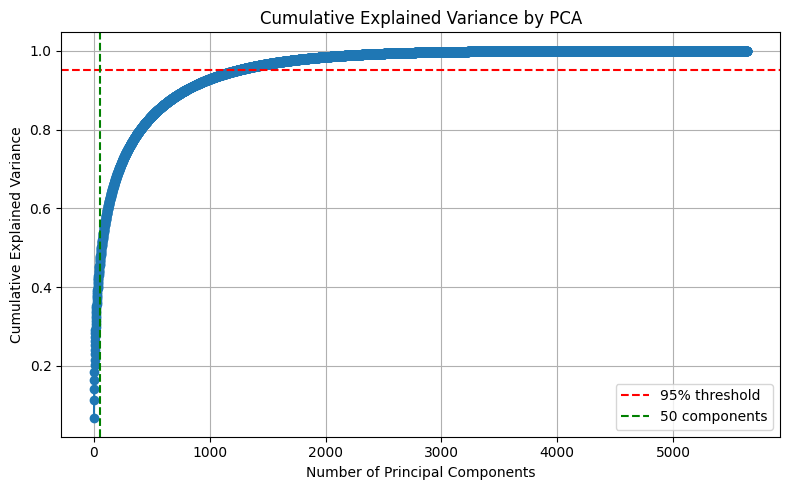

In [9]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Assume X_train contains the flattened ECG images
pca = PCA().fit(X_train)

# Calculate the cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot the cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.axvline(x=50, color='g', linestyle='--', label='50 components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


✔ Number of components needed for 95% variance: 1235


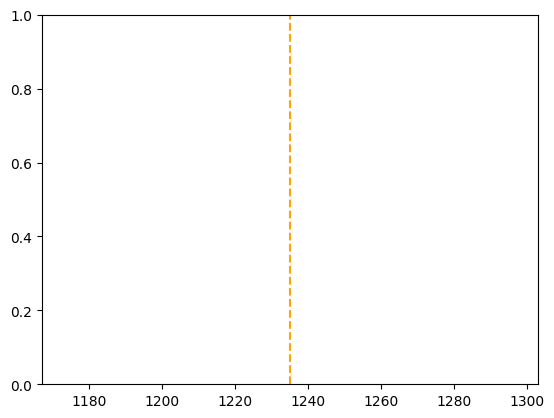

In [11]:
num_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"✔ Number of components needed for 95% variance: {num_95}")
plt.axvline(x=num_95, color='orange', linestyle='--', label=f'{num_95} components')


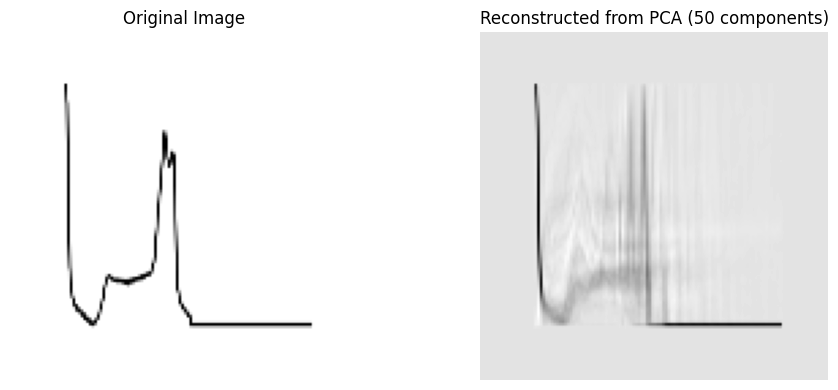

In [10]:
# Fit PCA with 50 components
pca_50 = PCA(n_components=50)
X_pca = pca_50.fit_transform(X_train)

# Select and reconstruct the first image
original = X_train[0].reshape(1, -1)
reconstructed = pca_50.inverse_transform(X_pca[0].reshape(1, -1))

# Plot original and reconstructed images
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(original.reshape(128, 128), cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed.reshape(128, 128), cmap='gray')
plt.title("Reconstructed from PCA (50 components)")
plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# --- Fit PCA with 50 components -----------------------------------
pca_50 = PCA(n_components=50)
X_pca = pca_50.fit_transform(X_train)

# --- Select and reconstruct the first image -----------------------
original = X_train[0].reshape(1, -1)
reconstructed = pca_50.inverse_transform(X_pca[0].reshape(1, -1))

# --- Convert for visualization ------------------------------------
original_img = original.reshape(128, 128)
reconstructed_img = reconstructed.reshape(128, 128)

# --- Plot original vs reconstructed -------------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_img, cmap='gray', aspect='auto')
plt.title("Original ECG Image", fontsize=12)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_img, cmap='gray', aspect='auto')
plt.title("Reconstructed from PCA (50 components)", fontsize=12)
plt.axis('off')

plt.suptitle("PCA Compression & Reconstruction", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
# Select a zoomed-in region (e.g., central 50x50 pixels)
zoom_start = 39
zoom_end = 89

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_img[zoom_start:zoom_end, zoom_start:zoom_end], cmap='gray')
plt.title("Original (Zoomed on ECG peak)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_img[zoom_start:zoom_end, zoom_start:zoom_end], cmap='gray')
plt.title("Reconstructed (Zoomed on ECG peak)")
plt.axis('off')

plt.suptitle("Zoom-in on ECG Morphology", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
from sklearn.decomposition import PCA
from skimage.metrics import mean_squared_error, structural_similarity as ssim
import matplotlib.pyplot as plt
import numpy as np

# --- Fit PCA with 50 components -----------------------------------
pca_50 = PCA(n_components=50)
X_pca = pca_50.fit_transform(X_train)

# --- Reconstruct the first image ----------------------------------
original = X_train[0].reshape(1, -1)
reconstructed = pca_50.inverse_transform(X_pca[0].reshape(1, -1))

# --- Reshape to image format --------------------------------------
original_img = original.reshape(128, 128)
reconstructed_img = reconstructed.reshape(128, 128)

# --- Normalize images for SSIM (optional) --------------------------
original_img_norm = (original_img - original_img.min()) / (original_img.max() - original_img.min())
reconstructed_img_norm = (reconstructed_img - reconstructed_img.min()) / (reconstructed_img.max() - reconstructed_img.min())

# --- Compute MSE --------------------------------------------------
mse_value = mean_squared_error(original_img, reconstructed_img)

# --- Compute SSIM -------------------------------------------------
ssim_value = ssim(original_img_norm, reconstructed_img_norm, data_range=1.0)

# --- Print results ------------------------------------------------
print(f"🔍 Mean Squared Error (MSE): {mse_value:.4f}")
print(f"🔍 Structural Similarity Index (SSIM): {ssim_value:.4f}")
